<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
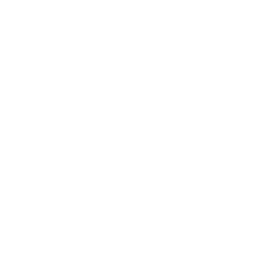
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Marktregime-identificatie</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Kwantitatieve financiën / Vermogensbeheer &nbsp;|&nbsp; Maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Dit voorbeeld gebruikt **PROC ACECLUS** om de latente structuur te vinden die marktregimes van elkaar scheidt, en clustert vervolgens op basis daarvan. Uit 100 wekelijkse observaties van 10 marktkenmerken (aandelenrendement en -volatiliteit, credit- en high-yield-spreads, de 2j/10j-curve, de dollar, grondstoffen en een VIX-verandering) schat ACECLUS een benaderende covariantie binnen regimes *zonder* enig regimelabel te gebruiken, en leidt het canonieke variabelen af waarlangs de regimes uiteenlopen.

Bij de drempel P=0.02 convergeert het algoritme in twee iteraties en behoudt het **drie canonieke dimensies**, die samen de volledige spreiding tussen regimes verklaren (eigenwaardeproporties 57.8%, 24.4%, 17.8%). Een lossere drempel P=0.05 verzacht de covariantie te sterk en **reduceert de structuur tot een enkele dimensie** — een nuttige waarschuwing dat de drempel het resultaat wezenlijk bepaalt.

Het invoeren van de drie canonieke variabelen in **PROC FASTCLUS** (k=4) levert een heldere ordening van de 100 weken naar stressernst op (totale R² = 0.51, pseudo F = 33.2): een kalme kern van 62 weken, een herstellende groep van 22 weken met afnemende volatiliteit, een groep van 12 weken met verhoogde stress, en een groep van 4 weken met diepe crisis waarin high-yield-spreads gemiddeld ~1,514 bps bedragen. Deze toewijzingen worden geëxporteerd voor stroomafwaartse conditionering van het portefeuillerisico.


## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Wekelijkse observaties van marktkenmerken over verschillende activaklassen | 100 |
| Variabelen: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

De reeks wordt gegenereerd door een Markov-regimeswitchproces met vijf toestanden (bull-expansie, late cyclus, risk-off, crisis, herstel) met regime-conditionele kenmerkverdelingen. Zonder licentie wordt de kenmerktabel beperkt tot de eerste 100 wekelijkse observaties (~2 jaar) — een door bull gedomineerd venster dat ook een korte crisis en herstel bezoekt. Wekelijkse rendementen en niveauveranderingen staan voor koersbewegingen aan het einde van de week; spreads zijn in basispunten en volatiliteit is een VIX-achtige index.


---

In [1]:
/* --------------------------------------------------------
   Genereer een wekelijkse multi-asset-markthistorie met vijf
   ingebedde regimestaten, aangedreven door een Markov-
   switchingproces. Dit uitgewerkte voorbeeld draait zonder
   licentie, dus de kenmerkentabel hieronder is beperkt tot de
   eerste 100 wekelijkse waarnemingen (~2 jaar) -- een door een
   stierenmarkt gedomineerd venster onderbroken door een korte
   crisis en herstel.
   -------------------------------------------------------- */
GEGEVENS work.market_weekly;
    CALL streaminit(42);
    /* 5 regimes: 1=Stier, 2=Laat-cyclus, 3=Risicomijding, 4=Crisis, 5=Herstel */
    REEKS regime_names[5] $16 _temporary_
        ('STIERENMARKT' 'LAAT_CYCLUS' 'RISICO_MIJDING'
         'CRISIS' 'HERSTEL');
    BEHOUDEN current_regime 1;
    DOE week_id = 1 TOT 5000;
        /* Markov-regimeswitching */
        u = rand('uniform');
        ALS current_regime = 1 DAN DOE; /* Stier: langlevend */
            ALS u > 0.97 DAN current_regime = 2;
        EINDE;
        ANDERS ALS current_regime = 2 DAN DOE; /* Laat-cyclus */
            ALS u > 0.92 DAN current_regime = 3;
        EINDE;
        ANDERS ALS current_regime = 3 DAN DOE; /* Risicomijding */
            ALS u > 0.80 DAN current_regime = 4;
            ANDERS ALS u < 0.10 DAN current_regime = 1;
        EINDE;
        ANDERS ALS current_regime = 4 DAN DOE; /* Crisis: kort */
            ALS u > 0.75 DAN current_regime = 5;
        EINDE;
        ANDERS ALS current_regime = 5 DAN DOE; /* Herstel */
            ALS u > 0.85 DAN current_regime = 1;
        EINDE;
        regime_label = regime_names[current_regime];
        /* Regime-afhankelijke kenmerkverdelingen */
        ALS current_regime = 1 DAN DOE;  /* Stier */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        EINDE;
        ANDERS ALS current_regime = 2 DAN DOE;  /* Laat-cyclus */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        EINDE;
        ANDERS ALS current_regime = 3 DAN DOE;  /* Risicomijding */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        EINDE;
        ANDERS ALS current_regime = 4 DAN DOE;  /* Crisis */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        EINDE;
        ANDERS DOE;  /* Herstel */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        EINDE;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        ALS week_id = 1 DAN vix_chg = 0;
        UITVOER;
    EINDE;
    VERWIJDEREN u;
    HERNOEMEN credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
    label eq_return_pct="Aandelenrendement (%)"
          eq_vol_idx="Aandelenvolatiliteitsindex"
          term_spread="Termijnspread" vix_chg="VIX-verandering"
          regime_label="Marktregime" yield_2y="2-jaarsrente"
          yield_10y="10-jaarsrente" usd_index_chg="USD-indexverandering"
          commodities_ret="Grondstoffenrendement";
UITVOEREN;



NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.38 seconds
  cpu   1.38 seconds


---

In [2]:
/* --------------------------------------------------------
   Basislijn-marktkenmerkverdelingen per regime
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.market_weekly n mean std MIN MAX;
    KLASSE regime_label;
    VARIABELE eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    label eq_return_pct="Aandelenrendement (%)" eq_vol_idx="Aandelenvolatiliteitsindex" credit_spread_bps="Kredietspread (bp)" hy_spread_bps="High-yield-spread (bp)" term_spread="Termijnspread" vix_chg="VIX-verandering" regime_label="Marktregime" CLUSTER="Cluster";
UITVOEREN;


                                                  The MEANS Procedure

                                Analysis Variable : eq_return_pct Aandelenrendement (%)

        Marktregime             N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------
        CRISIS                     12     -2.3403333      3.9436692     -8.0160000      3.7360000
        HERSTEL                     4      0.0077500      1.5951747     -0.8330000      2.4000000
        LAAT_CYCLUS                39      0.0364359      1.9733801     -4.6010000      3.7030000
        RISICO_MIJDING             17     -0.8447059      1.2832441     -3.3850000      1.1810000
        STIERENMARKT               28      0.2860000      1.0226518     -1.5980000      2.2150000
        -----------------------------------------------------------------------------------------

                               Analysis Variable : eq_v


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


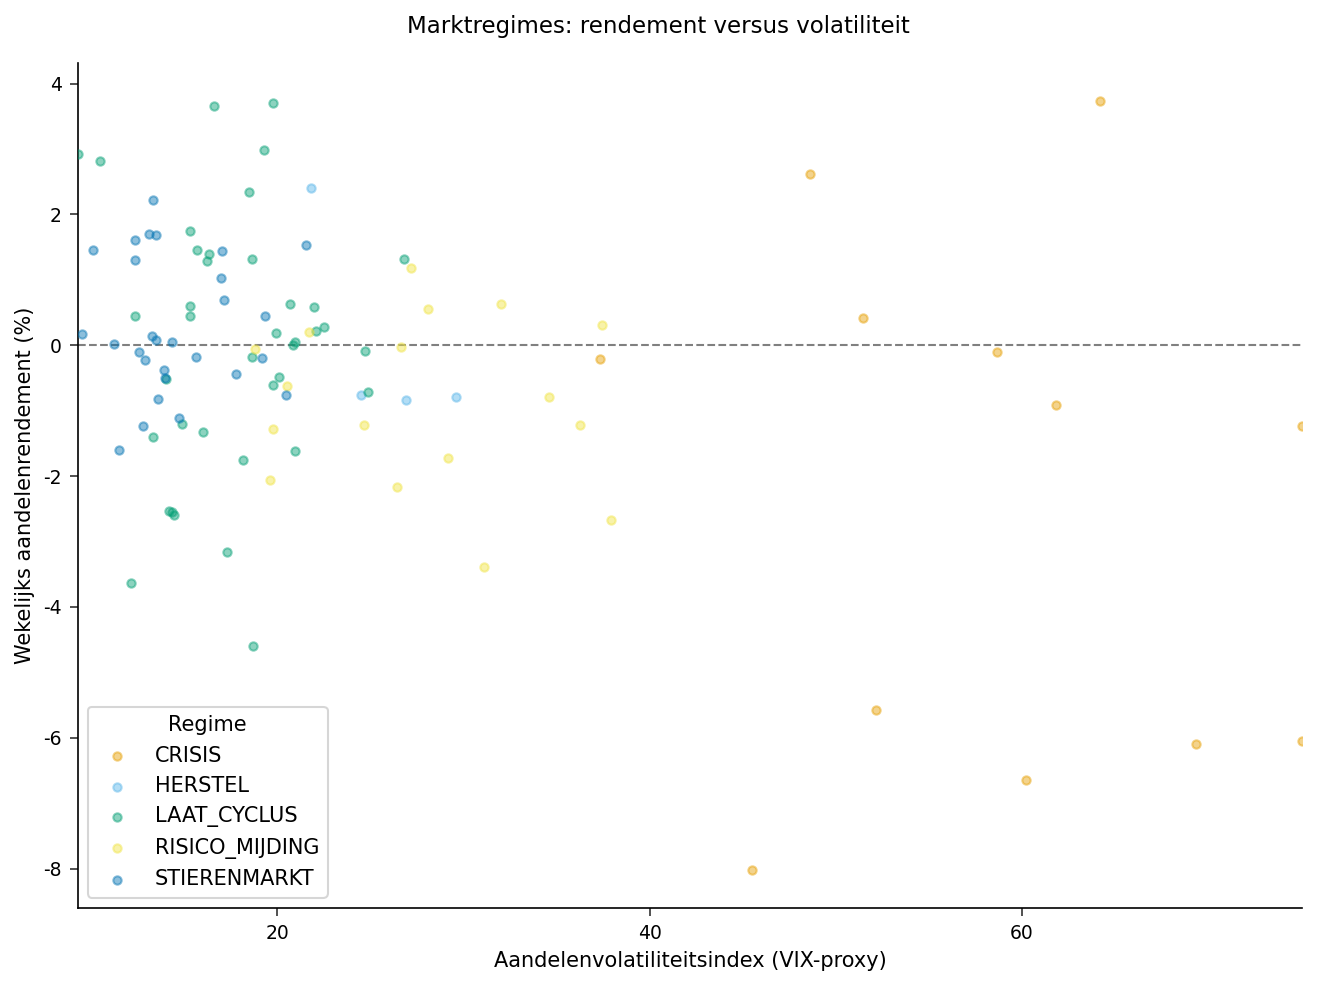

In [3]:
/* --------------------------------------------------------
   Aandelenrendement versus volatiliteitsindex per regimelabel
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS label='Aandelenvolatiliteitsindex (VIX-proxy)';
    YAXIS label='Wekelijks aandelenrendement (%)';
    keylegend / TITEL='Regime';
    TITEL 'Marktregimes: rendement versus volatiliteit';
UITVOEREN;


---

In [4]:
/* --------------------------------------------------------
   Benaderende schatting van de covariantie binnen regimes.
   ACECLUS schat de gepoolde covariantie binnen clusters
   zonder de clusterlabels te kennen, en leidt daaruit
   canonieke variabelen af die de regimes scheiden. P=0.02
   stelt de drempel voor paarsgewijze afstand in: alleen de
   ~2% dichtstbijzijnde waarnemingsparen worden als
   hetzelfde regime behandeld.
   -------------------------------------------------------- */
PROCEDURE aceclus GEGEVENS=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VARIABELE eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
UITVOEREN;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
Aandelenrendement (%)      -0.3298       2.1334
Aandelenvolatiliteitsindex      23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
2-jaarsrente               2.8713       1.4029
10-jaarsrente              3.1472       1.0815
Termijnspread              0.2697       0.9969
USD-indexverandering      -0.0184       0.8046
Grondstoffenrendement      -0.3444       1.3444
VIX-verandering            0.0036      10.5153

COV: Total Sample Covariances
Aandelenrendement (%)     4.551470   -12.057896   -94.993895  -263.463256     


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Gevoeligheidscheck bij P=0.05 -- een lossere drempel voor
   hetzelfde regime trekt meer paren aan en blaast de
   geschatte covariantie binnen regimes op. Vergelijk de
   canonieke structuur (eigenwaarden en behouden dimensies)
   met de P=0.02-oplossing.
   -------------------------------------------------------- */
PROCEDURE aceclus GEGEVENS=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VARIABELE eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
UITVOEREN;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
Aandelenrendement (%)      -0.3298       2.1334
Aandelenvolatiliteitsindex      23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
2-jaarsrente               2.8713       1.4029
10-jaarsrente              3.1472       1.0815
Termijnspread              0.2697       0.9969
USD-indexverandering      -0.0184       0.8046
Grondstoffenrendement      -0.3444       1.3444
VIX-verandering            0.0036      10.5153

COV: Total Sample Covariances
Aandelenrendement (%)     4.551470   -12.057896   -94.993895  -263.463256     


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means op de canonieke ACECLUS-variabelen. ACECLUS
   behield drie canonieke dimensies (Can1-Can3), dus de
   clustering draait daarop. Vier clusters richten zich op de
   vier goed bevolkte marktstaten.
   -------------------------------------------------------- */
PROCEDURE FASTCLUS GEGEVENS=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VARIABELE can1 can2 can3;
UITVOEREN;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                       Regimecluster versus werkelijk regimelabel                                       

                                                   The FREQ Procedure

Table of Cluster by Marktregime

Cluster |        CRISIS |       HERSTEL |   LAAT_CYCLUS |RISICO_MIJDING |  STIERENMARKT |          Total
--------+---------------+---------------+---------------+---------------+---------------+---------------
1       |             4 |             0 |             2 |             4 |             2 |             12
        |          4.00 |          0.00 |          2.00 |          4.00 |          2.00 |          12.00
--------+---------------+---------------+---------------+---------------+---------------+---------------
2       |             3 |             3 |            28 |             7 |            21 |             62
        |          3.00 |          3.00 |         28.00 |          7.00 |         21.00 |          62.00
--------+---------------+--------------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


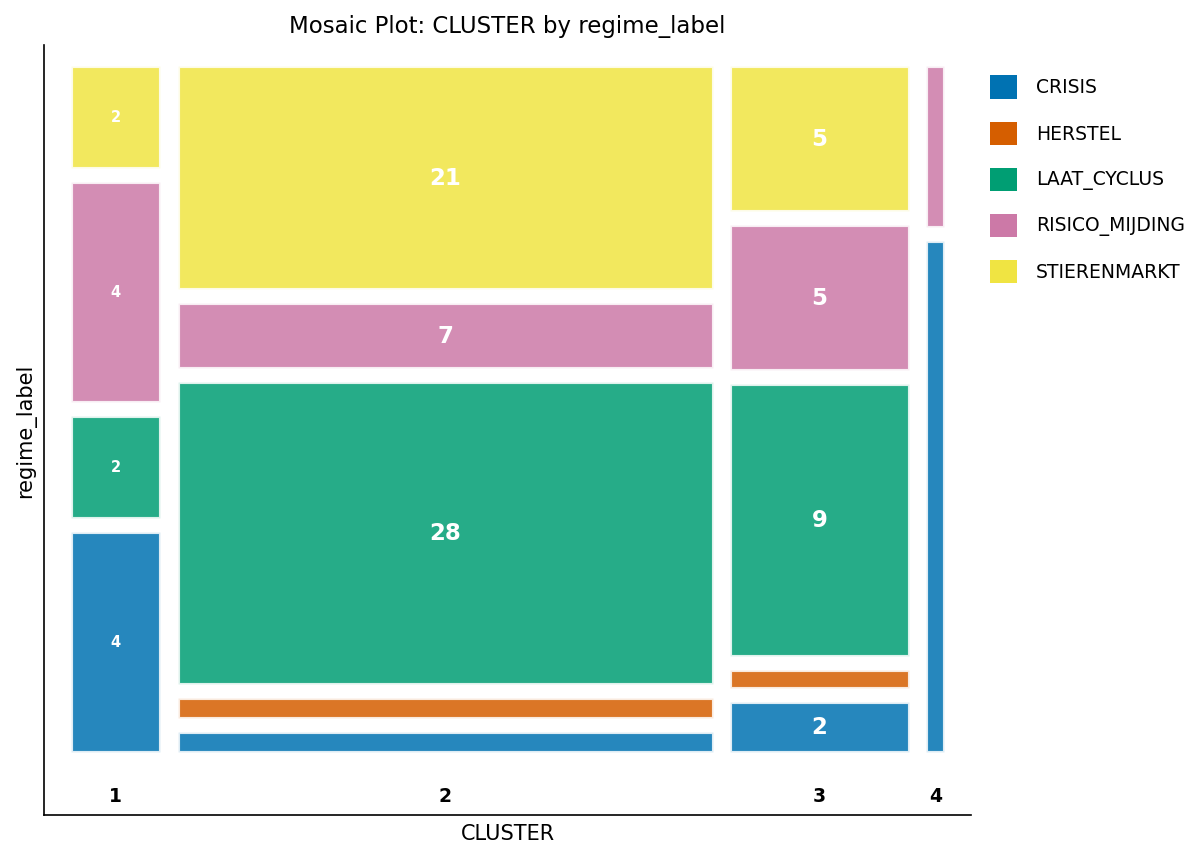

In [7]:
/* --------------------------------------------------------
   Valideer toegewezen clusters tegen bekende
   regimelabels uit de datageneratie
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    label CLUSTER="Cluster" regime_label="Marktregime";
    TITEL 'Regimecluster versus werkelijk regimelabel';
UITVOEREN;


In [8]:
/* --------------------------------------------------------
   Profileer regimekenmerkgemiddelden voor interpretatie
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.regime_assignments mean;
    KLASSE CLUSTER;
    VARIABELE eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    label eq_return_pct="Aandelenrendement (%)" eq_vol_idx="Aandelenvolatiliteitsindex" credit_spread_bps="Kredietspread (bp)" hy_spread_bps="High-yield-spread (bp)" term_spread="Termijnspread" vix_chg="VIX-verandering" regime_label="Marktregime" CLUSTER="Cluster";
UITVOEREN;


                                       Regimecluster versus werkelijk regimelabel                                       

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Aandelenrendement (%)

                                                          N
                                             Cluster    Obs            Mean
                                             ------------------------------
                                             1           12      -2.0955000
                                             2           62      -0.3638871
                                             3           22       0.7421364
                                             4            4      -0.4010000
                                             ------------------------------

                                             Analysis Variable : eq_vol_idx Aandelenvolatiliteitsindex

        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretatie

**Canonieke structuur van ACECLUS.** Op de steekproef van 100 weken convergeerde PROC ACECLUS (P=0.02, drempel = 2.578941) in twee iteraties en produceerde drie canonieke variabelen. Hun eigenwaarden van `Inv(ACE)*(COV-ACE)` zijn 0.0219, 0.0093 en 0.0067, d.w.z. proporties van 57.8%, 24.4% en 17.8% (cumulatief 100%). De eerste canonieke as draagt het dominante risk-on/risk-off-contrast; de tweede en derde verfijnen het. Omdat de aandelenvolatiliteit en de spread-kenmerken sterk samen bewegen, vouwt ACECLUS die gedeelde variatie in de covariantie binnen regimes, zodat de canonieke assen echte scheiding tussen regimes weerspiegelen in plaats van gemeenschappelijke schaal.

**Drempelgevoeligheid.** Opnieuw uitvoeren bij P=0.05 verhoogt de afstandsdrempel tot 2.899704, waardoor 4,949 van de 4,950 observatieparen binnen de grens vallen. De geschatte covariantie binnen regimes is dan bijna gelijk aan de totale covariantie, en de canonieke structuur **reduceert tot een enkele dimensie** (één eigenwaarde, 0.0096, op 100%). De oplossingen bij P=0.02 en P=0.05 zijn hier daarom *niet* uitwisselbaar — een lossere drempel wist de fijnere regime-assen uit, zodat de strakkere drempel de meer informatieve specificatie voor deze steekproef is.

**Clustering op de canonieke variabelen.** PROC FASTCLUS (k=4) op Can1–Can3 geeft een totale R² van 0.5089 en een pseudo F van 33.16. Can2 doet het meeste scheidingswerk (R² = 0.626), Can1 draagt matig bij (R² = 0.359), en Can3 voegt vrijwel niets toe (R² = 0.000) — consistent met slechts twee assen die een sterk signaal dragen. De vier clusters vormen een gradiënt van marktstress:

| Cluster | n | Gem. aandelenrendement | Gem. VIX | Gem. HY-spread | Gem. VIX-verandering | Interpretatie |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Kalme kern (bull / late cyclus) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Herstellend, volatiliteit dalend |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Verhoogde stress, volatiliteit piekend |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Diepe crisis, extreme kredietstress |

**Cluster versus werkelijk regime.** De kruistabel toont dat de clusters niet één-op-één overeenkomen met de vijf genererende labels — te verwachten, omdat de labels bij deze steekproefomvang sterk overlappen in de kenmerkruimte. Het grote kalme cluster (62) absorbeert de meeste bull- (21) en late-cyclus- (28) weken; het diepe-crisiscluster (4) bestaat vrijwel volledig uit de meest extreme crisisweken (3 van 4). De canonieke assen ordenen de weken dus naar *ernst*, niet naar exact label, wat het bruikbaardere signaal is voor risicoconditionering.

**Gebruik.** De geëxporteerde wekelijkse toewijzingen ondersteunen tactische conditionering: verminder risico en verleng de looptijd naarmate weken naar Clusters 1 en 4 verschuiven, en neem opnieuw risico wanneer ze terugkeren naar de kalme kern (Cluster 2) of de herstellende groep (Cluster 3).


---

In [9]:
/* --------------------------------------------------------
   Exporteer wekelijkse regimetoewijzingen voor conditionering
   van het portefeuillerisicomodel en signaalgeneratie
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>